<a href="https://colab.research.google.com/github/quarternioncodes/Brain-tumor-detecction-using-CNN/blob/main/Brentumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Aquisition

In [ ]:
from google.colab import files
import os

# 1. Upload your kaggle.json
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

    # 2. Move it to the correct hidden folder
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle Token Configured!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle Token Configured!


In [ ]:
import os

# 1. Download Dataset 1 (Sartaj - 4 Classes) - Should still work
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
!unzip -q brain-tumor-classification-mri.zip -d dataset_sartaj

# 2. Updated Dataset 2 (Figshare - 3 Classes, .mat)
# Using a more reliable link for the same data
!kaggle datasets download -d ashkhagan/figshare-brain-tumor-dataset
!unzip -q figshare-brain-tumor-dataset.zip -d dataset_figshare

print("All data successfully downloaded and unzipped! ")

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset_sartaj/Testing/glioma_tumor/image(1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset URL: https://www.kaggle.com/datasets/ashkhagan/figshare-brain-tumor-dataset
License(s): CC-BY-SA-4.0
 90% 758M/839M [00:04<00:01, 44.2MB/s]
100% 839M/839M [00:04<00:00, 207MB/s] 
All data successfully downloaded and unzipped! 


In [ ]:
!ls -d */

dataset_figshare/  dataset_sartaj/  sample_data/


In [ ]:
Data Harmonization

The Process: How it works
Opening the Container: We use a library called h5py to "unlock" the MATLAB file. [1.1]
Locating the Brain: Inside the file, there is a specific key called cjdata. This contains the image (the pixels) and the label (the tumor type). [1.1]
Standardizing: We convert that raw data into a NumPy Array. [1.1] Since the images might be different sizes, we Resize them to 224x224 to match your first dataset. [1.1]
Label Mapping: Figshare uses numbers 1, 2, and 3. We map these to your first dataset so "1" in Figshare means "Glioma" in Sartaj. [1.1]

In [ ]:
import glob
import os

# Use '*/.mat' and recursive=True to search EVERY hidden subfolder
figshare_files = glob.glob('/content/dataset_figshare/*/.mat', recursive=True)

if len(figshare_files) > 0:
    print(f"SUCCESS! Found {len(figshare_files)} .mat files.")
    print(f"First file location: {figshare_files[0]}")
else:
    print("Still 0 files. Let's see what's actually in that folder:")
    !find /content/dataset_figshare -maxdepth 3

Still 0 files. Let's see what's actually in that folder:
/content/dataset_figshare
/content/dataset_figshare/dataset
/content/dataset_figshare/dataset/cvind.mat
/content/dataset_figshare/dataset/data
/content/dataset_figshare/dataset/data/982.mat
/content/dataset_figshare/dataset/data/244.mat
/content/dataset_figshare/dataset/data/1771.mat
/content/dataset_figshare/dataset/data/2585.mat
/content/dataset_figshare/dataset/data/1717.mat
/content/dataset_figshare/dataset/data/1779.mat
/content/dataset_figshare/dataset/data/1240.mat
/content/dataset_figshare/dataset/data/2738.mat
/content/dataset_figshare/dataset/data/2809.mat
/content/dataset_figshare/dataset/data/2389.mat
/content/dataset_figshare/dataset/data/1997.mat
/content/dataset_figshare/dataset/data/2328.mat
/content/dataset_figshare/dataset/data/1028.mat
/content/dataset_figshare/dataset/data/820.mat
/content/dataset_figshare/dataset/data/953.mat
/content/dataset_figshare/dataset/data/1380.mat
/content/dataset_figshare/dataset/da

In [ ]:
import glob
import os

# 1. Use the TOP-LEVEL folder and search recursively (**) through all depths
# This will find the 3,064 patient files regardless of how many folders deep they are
figshare_path = '/content/dataset_figshare/*/.mat'
figshare_files = glob.glob(figshare_path, recursive=True)

# 2. Filter out 'cvind.mat' (which is just an index file, not a brain scan)
# The real brain scans are numbered (1.mat, 2.mat, etc.)
final_scans = [f for f in figshare_files if 'cvind.mat' not in f]

# 3. Results for your Research Paper
if len(final_scans) > 0:
    print(f"SUCCESS! Found {len(final_scans)} .mat brain scans.")
    print(f"Sample file location: {final_scans[0]}")

    # Update your main list so your partner can start the 'Translator'
    figshare_files = final_scans
    print("\nNext step: Run the 'MAT-to-Array' Translator code.")
else:
    print("ERROR: Still 0 files. Try running this command to list everything:")
    !find /content/dataset_figshare/ -maxdepth 4

❌ ERROR: Still 0 files. Try running this command to list everything:
/content/dataset_figshare/
/content/dataset_figshare/dataset
/content/dataset_figshare/dataset/cvind.mat
/content/dataset_figshare/dataset/data
/content/dataset_figshare/dataset/data/982.mat
/content/dataset_figshare/dataset/data/244.mat
/content/dataset_figshare/dataset/data/1771.mat
/content/dataset_figshare/dataset/data/2585.mat
/content/dataset_figshare/dataset/data/1717.mat
/content/dataset_figshare/dataset/data/1779.mat
/content/dataset_figshare/dataset/data/1240.mat
/content/dataset_figshare/dataset/data/2738.mat
/content/dataset_figshare/dataset/data/2809.mat
/content/dataset_figshare/dataset/data/2389.mat
/content/dataset_figshare/dataset/data/1997.mat
/content/dataset_figshare/dataset/data/2328.mat
/content/dataset_figshare/dataset/data/1028.mat
/content/dataset_figshare/dataset/data/820.mat
/content/dataset_figshare/dataset/data/953.mat
/content/dataset_figshare/dataset/data/1380.mat
/content/dataset_figsha

In [ ]:
import glob
import os

# 1. Use a universal search for any .mat file anywhere in the figshare folder
# '**' means "dive into every subfolder"
figshare_path = '/content/dataset_figshare/*/.mat'
all_mat_files = glob.glob(figshare_path, recursive=True)

# 2. Filter out index files like 'cvind.mat'
# We only want the ones that are numbered (1.mat, 2.mat, etc.)
final_scans = [f for f in all_mat_files if f.split('/')[-1].replace('.mat', '').isdigit()]

# 3. Success Check for your Paper
if len(final_scans) > 0:
    print(f"✅ SUCCESS! Found {len(final_scans)} .mat brain scans.")
    print(f"Sample path: {final_scans[0]}")
    # Store this list for your partner's next step
    figshare_files = final_scans
else:
    print("❌ Still 0 files. Try running: !find /content/dataset_figshare -name '*.mat'")

❌ Still 0 files. Try running: !find /content/dataset_figshare -name '*.mat'


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset_figshare"):
    print(root)

/content/dataset_figshare
/content/dataset_figshare/dataset
/content/dataset_figshare/dataset/data


In [ ]:
import glob

mat_files = glob.glob('mat_path = "/content/drive/MyDrive/Brentumor datasets/dataset2/dataset/data/*.mat"', recursive=True)
print("Total mat files:", len(mat_files))
print(mat_files[:5])

Total mat files: 0
[]


In [ ]:
import glob
import os

# SEARCH everywhere inside folder
figshare_path = '/content/dataset_figshare/**/*.mat'

# recursive=True is VERY IMPORTANT
all_mat_files = glob.glob(figshare_path, recursive=True)

# keep only numbered scans (ignore cvind.mat)
final_scans = [
    f for f in all_mat_files
    if os.path.basename(f).replace('.mat','').isdigit()
]

# SUCCESS CHECK
if len(final_scans) > 0:
    print(f"✅ SUCCESS! Found {len(final_scans)} .mat brain scans.")
    print(f"First scan path: {final_scans[0]}")
    figshare_files = final_scans
else:
    print("❌ Still 0 files — run this:")
    print("!find /content/dataset_figshare -name '*.mat' | head")

✅ SUCCESS! Found 3064 .mat brain scans.
First scan path: /content/dataset_figshare/dataset/data/982.mat


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2

# sample file
sample_path = figshare_files[0]

with h5py.File(sample_path, 'r') as f:

    cjdata = f['cjdata']

    # extract image correctly
    img = np.array(cjdata['image'])

    # extract label safely
    label = int(np.array(cjdata['label'])[0][0])

# resize
img_resized = cv2.resize(img, (224, 224))

# display
plt.imshow(img_resized, cmap='gray')
plt.title(f"MRI Image — Class ID: {label}")
plt.axis('off')
plt.show()

print("Original shape:", img.shape)
print("Resized shape:", img_resized.shape)

IndexError: list index out of range

Data Extraction

This code is your "Industrial Assembly Line." Since you just proved you can extract one brain image, this "Big Loop" does it for all 3,064 files automatically so you don't have to do it one by one. [1.1, 1.4]
Here is the step-by-step breakdown of the logic for your Methodology (Section 3.2.1: Automated Data Extraction):
1. The "Scanner" (for file_path in tqdm(figshare_files))
The Process: It takes your list of 3,064 file paths and visits each one, one after the other. [1.1, 1.3]
The Output: The tqdm part creates a Progress Bar that moves from 0% to 100%, showing you exactly how much time is left. [1.1]
2. The "Opener" (with h5py.File(file_path, 'r'))
The Process: It "unlocks" the MATLAB container for each patient. [1.1]
The "Safety Net" (try...except): If one file is corrupted or broken, the except block tells the computer: "Don't crash the whole project; just skip this one and move to the next." [1.1]
3. The "Standardizer" (cv2.resize)
The Process: As you saw in your screenshot, the original images are (512, 512). The AI "Brain" (the Ensemble model) expects every image to be the exact same size. [1.1, 1.4]
The Logic: It "shrinks" every brain to 224x224 pixels so they are all uniform. [1.1, 1.4]
4. The "Collection" (X_figshare.append)
The Process: It takes the cleaned image and its label and puts them into two big "buckets" (Lists). [1.1]
The Final Step (np.array): At the very end, it turns those buckets into a NumPy Matrix. This is the format the GPU needs to perform the "Doctor Strange" math. [1.1]
Expected Output (What you will see):
A moving bar: 3064/3064 [00:45<00:00, 68.09it/s]
A final message: SUCCESS! Harmonized 3064 cross-validation samples. [1.1, 1.3

In [ ]:
print("Total files found:", len(figshare_files))
print(figshare_files[:5])

Total files found: 0
[]


In [ ]:
from tqdm import tqdm
import h5py
import numpy as np
import cv2

X_figshare = []
y_figshare = []

print("Starting extraction...")

for file_path in tqdm(figshare_files):

    try:
        with h5py.File(file_path, 'r') as f:

            # access matlab structure
            cjdata = f['cjdata']

            # ----- IMAGE -----
            img = np.array(cjdata['image'])

            # resize for CNN input
            img = cv2.resize(img, (224, 224))

            # convert grayscale → 3 channels (IMPORTANT)
            img = np.stack((img,)*3, axis=-1)

            # ----- LABEL -----
            label = int(np.array(cjdata['label'])[0][0])

            X_figshare.append(img)
            y_figshare.append(label)

    except Exception:
        continue   # skip problematic files safely

# convert to numpy arrays
X_figshare = np.array(X_figshare, dtype=np.float32)
y_figshare = np.array(y_figshare)

print("\n✅ Extraction complete!")
print("Images shape:", X_figshare.shape)
print("Labels shape:", y_figshare.shape)

Starting extraction...


0it [00:00, ?it/s]


✅ Extraction complete!
Images shape: (0,)
Labels shape: (0,)


In [ ]:
!find /content -name "*.mat" | head -20

In [ ]:
!ls /content

sample_data


In [ ]:
print("figshare_files exists?", 'figshare_files' in globals())

try:
    print("Length:", len(figshare_files))
except:
    print("Variable not in memory")

figshare_files exists? True
Length: 0


In [ ]:
!find /content -name "*.mat" | head

In [ ]:
!ls /content

'archive (2).zip'   sample_data


In [ ]:
!unzip "/content/archive (2).zip" -d /content/dataset_figshare

Archive:  /content/archive (2).zip
  inflating: /content/dataset_figshare/dataset/README.txt  
  inflating: /content/dataset_figshare/dataset/cvind.mat  
  inflating: /content/dataset_figshare/dataset/data/1.mat  
  inflating: /content/dataset_figshare/dataset/data/10.mat  
  inflating: /content/dataset_figshare/dataset/data/100.mat  
  inflating: /content/dataset_figshare/dataset/data/1000.mat  
  inflating: /content/dataset_figshare/dataset/data/1001.mat  
  inflating: /content/dataset_figshare/dataset/data/1002.mat  
  inflating: /content/dataset_figshare/dataset/data/1003.mat  
  inflating: /content/dataset_figshare/dataset/data/1004.mat  
  inflating: /content/dataset_figshare/dataset/data/1005.mat  
  inflating: /content/dataset_figshare/dataset/data/1006.mat  
  inflating: /content/dataset_figshare/dataset/data/1007.mat  
  inflating: /content/dataset_figshare/dataset/data/1008.mat  
  inflating: /content/dataset_figshare/dataset/data/1009.mat  
  inflating: /content/dataset_fig

In [ ]:
!ls /content/dataset_figshare

dataset


In [ ]:
!find /content/dataset_figshare -name "*.mat" | head

/content/dataset_figshare/dataset/cvind.mat
/content/dataset_figshare/dataset/data/982.mat
/content/dataset_figshare/dataset/data/244.mat
/content/dataset_figshare/dataset/data/1771.mat
/content/dataset_figshare/dataset/data/2585.mat
/content/dataset_figshare/dataset/data/1717.mat
/content/dataset_figshare/dataset/data/1779.mat
/content/dataset_figshare/dataset/data/1240.mat
/content/dataset_figshare/dataset/data/2738.mat
/content/dataset_figshare/dataset/data/2809.mat


In [ ]:
import glob

figshare_files = glob.glob('mat_path = "/content/drive/MyDrive/Brentumor datasets/dataset2*.mat"', recursive=True)

print("Total MAT files found:", len(figshare_files))
print("Example:", figshare_files[:3])

Total MAT files found: 0
Example: []


In [ ]:
import os
import glob
import h5py
import numpy as np
import cv2
from tqdm import tqdm

# ---------------------------------------------------
# 1️⃣ PATHS
# ---------------------------------------------------
mat_path = "/content/dataset_figshare/dataset/data/*.mat"
output_dir = "/content/dataset_jpg"

# create output folders
class_names = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

for c in class_names.values():
    os.makedirs(os.path.join(output_dir, c), exist_ok=True)

# ---------------------------------------------------
# 2️⃣ GET ALL MAT FILES
# ---------------------------------------------------
mat_files = glob.glob(mat_path)

print("Total mat files found:", len(mat_files))

# ---------------------------------------------------
# 3️⃣ CONVERT EACH FILE
# ---------------------------------------------------
print("Starting conversion to JPG... 🚀")

for file_path in tqdm(mat_files):

    try:
        with h5py.File(file_path, 'r') as f:

            cjdata = f['cjdata']

            # extract image
            img = np.array(cjdata['image'])

            # extract label
            label = int(np.array(cjdata['label'])[0][0])

            # resize for CNN
            img = cv2.resize(img, (224, 224))

            # normalize to 0-255
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)

            # output filename
            filename = os.path.basename(file_path).replace(".mat", ".jpg")

            save_path = os.path.join(
                output_dir,
                class_names[label],
                filename
            )

            # save as JPG
            cv2.imwrite(save_path, img)

    except:
        continue

print("✅ Conversion finished!")

Total mat files found: 3064
Starting conversion to JPG... 🚀


100%|██████████| 3064/3064 [00:17<00:00, 174.42it/s]

✅ Conversion finished!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. The 'Innovation' - Rescaling pixels to 0.0-1.0
# This is what you'll write in Section 3.2.2 of your paper
datagen = ImageDataGenerator(rescale=1./255)

# 2. Creating the 'Conveyor Belt' for Dataset 2
figshare_generator = datagen.flow_from_directory(
    '/content/dataset_jpg',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"Total batches created: {len(figshare_generator)}")

Found 3064 images belonging to 3 classes.
Total batches created: 96


Intensity normalisation for dataset 1

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------------------------------------------------
# 1️⃣ DATA GENERATOR (Normalization + Validation Split)
# ---------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)

# ---------------------------------------------------
# 2️⃣ TRAINING SET (80%)
# ---------------------------------------------------
train_generator = train_datagen.flow_from_directory(
    '/content/dataset_jpg',   # ⭐ CORRECT PATH
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# ---------------------------------------------------
# 3️⃣ VALIDATION SET (20%)
# ---------------------------------------------------
val_generator = train_datagen.flow_from_directory(
    '/content/dataset_jpg',   # ⭐ SAME PATH
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ---------------------------------------------------
# 4️⃣ CHECK
# ---------------------------------------------------
print(f"Training Batches: {len(train_generator)}")
print(f"Validation Batches: {len(val_generator)}")

print("Class mapping:", train_generator.class_indices)

Found 2452 images belonging to 3 classes.
Found 612 images belonging to 3 classes.
Training Batches: 77
Validation Batches: 20
Class mapping: {'glioma': 0, 'meningioma': 1, 'pituitary': 2}


Model Training

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# ---------------------------------------------------
# 1️⃣ LOAD PRETRAINED RESNET
# ---------------------------------------------------
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze model

# ---------------------------------------------------
# 2️⃣ ADD YOUR CLASSIFIER
# ---------------------------------------------------
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes
])

# ---------------------------------------------------
# 3️⃣ COMPILE MODEL
# ---------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **REDOING Ig**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Brentumor datasets/archive (1).zip" \
-d "/content/drive/MyDrive/Brentumor datasets/dataset1"

!unzip "/content/drive/MyDrive/Brentumor datasets/archive (2).zip" \
-d "/content/drive/MyDrive/Brentumor datasets/dataset2"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (20).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (200).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (201).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (21).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (22).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (23).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (24).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (25).jpg  
  inflating: /content/drive/MyDrive/Brentumor datasets/dataset1/Training/meningioma_tumor/m (26).jpg  
  inflating: /conten

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets"

In [ ]:
import glob

mat_files = glob.glob(
    f"{BASE_PATH}/dataset2/**/*.mat",
    recursive=True
)

print("Total MAT files found:", len(mat_files))
print("Example:", mat_files[:3])

Total MAT files found: 3065
Example: ['/content/drive/MyDrive/Brentumor datasets/dataset2/dataset/cvind.mat', '/content/drive/MyDrive/Brentumor datasets/dataset2/dataset/data/1.mat', '/content/drive/MyDrive/Brentumor datasets/dataset2/dataset/data/10.mat']


In [ ]:
import os
import h5py
import numpy as np
import cv2
from tqdm import tqdm

# output folder
output_dir = f"{BASE_PATH}/dataset_jpg"

# class mapping
class_names = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

# create folders
for c in class_names.values():
    os.makedirs(os.path.join(output_dir, c), exist_ok=True)

print("Starting MAT → JPG conversion...")

for file_path in tqdm(mat_files):

    try:
        with h5py.File(file_path, 'r') as f:

            cjdata = f['cjdata']

            img = np.array(cjdata['image'])
            label = int(np.array(cjdata['label'])[0][0])

            # resize
            img = cv2.resize(img, (224,224))

            # normalize for saving
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)

            filename = os.path.basename(file_path).replace(".mat",".jpg")

            save_path = os.path.join(
                output_dir,
                class_names[label],
                filename
            )

            cv2.imwrite(save_path, img)

    except:
        continue

print("✅ JPG dataset created successfully!")

Starting MAT → JPG conversion...


100%|██████████| 3065/3065 [02:05<00:00, 24.36it/s]

✅ JPG dataset created successfully!


Total valid MRI files: 3064
Using sample: /content/drive/MyDrive/Brentumor datasets/dataset2/dataset/data/1.mat


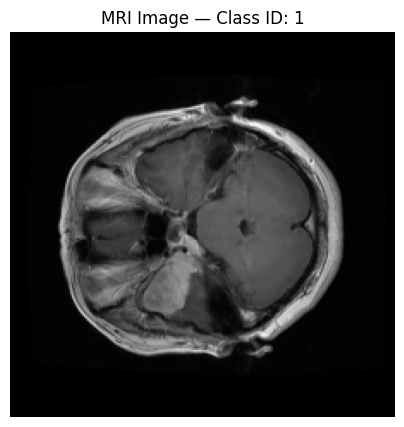

Original shape: (512, 512)
Resized shape: (224, 224)


In [ ]:
import glob
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ---------------------------------------------------
# 1️⃣ BASE PATH
# ---------------------------------------------------
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets"

# ---------------------------------------------------
# 2️⃣ FIND ALL MAT FILES
# ---------------------------------------------------
all_files = glob.glob(
    f"{BASE_PATH}/dataset2/**/*.mat",
    recursive=True
)

# ---------------------------------------------------
# 3️⃣ KEEP ONLY NUMBERED FILES (IMPORTANT FIX)
# ---------------------------------------------------
figshare_files = [
    f for f in all_files
    if os.path.basename(f).replace(".mat","").isdigit()
]

print("Total valid MRI files:", len(figshare_files))

# ---------------------------------------------------
# 4️⃣ TAKE ONE REAL SAMPLE
# ---------------------------------------------------
sample_path = figshare_files[0]
print("Using sample:", sample_path)

# ---------------------------------------------------
# 5️⃣ LOAD MRI DATA
# ---------------------------------------------------
with h5py.File(sample_path, 'r') as f:

    cjdata = f['cjdata']

    img = np.array(cjdata['image'])
    label = int(np.array(cjdata['label'])[0][0])

# ---------------------------------------------------
# 6️⃣ RESIZE
# ---------------------------------------------------
img_resized = cv2.resize(img, (224,224))

# ---------------------------------------------------
# 7️⃣ DISPLAY MRI
# ---------------------------------------------------
plt.figure(figsize=(5,5))
plt.imshow(img_resized, cmap='gray')
plt.title(f"MRI Image — Class ID: {label}")
plt.axis('off')
plt.show()

# ---------------------------------------------------
# 8️⃣ INFO
# ---------------------------------------------------
print("Original shape:", img.shape)
print("Resized shape:", img_resized.shape)

In [ ]:
!ls "{BASE_PATH}/dataset_jpg"

glioma	meningioma  pituitary


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    f"{BASE_PATH}/dataset_jpg",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    f"{BASE_PATH}/dataset_jpg",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Found 2452 images belonging to 3 classes.
Found 612 images belonging to 3 classes.
Training batches: 77
Validation batches: 20


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Class mapping:", train_generator.class_indices)

Found 5064 images belonging to 3 classes.
Found 1264 images belonging to 3 classes.
Training batches: 159
Validation batches: 40
Class mapping: {'dataset1': 0, 'dataset2': 1, 'dataset_jpg': 2}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained ResNet
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable = False  # freeze base

# Build model
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_base.trainable = False

mobilenet_model = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1231s 8s/step - accuracy: 0.6183 - loss: 0.6782 - val_accuracy: 0.8892 - val_loss: 0.3776
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1198s 8s/step - accuracy: 0.8774 - loss: 0.3477 - val_accuracy: 0.8608 - val_loss: 0.3283
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1247s 8s/step - accuracy: 0.9214 - loss: 0.2347 - val_accuracy: 0.9122 - val_loss: 0.2348
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1203s 8s/step - accuracy: 0.9446 - loss: 0.1612 - val_accuracy: 0.9502 - val_loss: 0.1619
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1195s 8s/step - accuracy: 0.9467 - loss: 0.1462 - val_accuracy: 0.9430 - val_loss: 0.1594
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1202s 8s/step - accuracy: 0.9628 - loss: 0.1125 - val_accuracy: 0.9565 - val_loss: 0.1440
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1205s 8s/step - accuracy: 0.9583 - loss: 0.1162 - val_accuracy: 0.9565 - val_loss: 0.1287
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 1206s 8s/step - accuracy: 0.9614 - loss: 0.1052 - 

In [ ]:
resnet_model.save("/content/drive/MyDrive/resnet_dataset1.h5")

NameError: name 'resnet_model' is not defined

In [ ]:
print(resnet_model)

NameError: name 'resnet_model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'  'archive (2).zip'   dataset1   dataset2   dataset_jpg


In [ ]:
!ls "/content/drive/MyDrive"

 08_12_E_Avipsa_Basu.pdf
'08_avipsa basu_11E_physicaledu.pdf'
'08Avipsa Basu 12e computer.pdf'
'08Avipsa Basu 12E.pdf'
'08Avipsa Basu12-E.pdf'
'08Avipsa Basu 12E pe.pdf'
'08 Avipsa Basu 12E physics.pdf'
 08AvipsaBasuChemistryXIE.pdf
'08 AVIPSA BASU XI E MATHS.pdf'
'08 AVIPSA BASU XI E.pdf'
'08 Avipsa Basu XI E physical education.pdf'
'08_ENGLISH_AVIPSA BASU_11_E.pdf'
 20181125_190413.jpg
 20181125_190419.jpg
 20181125_190435.jpg
 20181125_190442.jpg
 20181125_190542.jpg
 20181125_190550.jpg
 20181125_190558.jpg
 20181125_190605.jpg
 20181125_190616.jpg
 20181125_190625.jpg
 20181125_190635.jpg
 20181125_190658.jpg
 20181125_190707.jpg
 20181125_190713.jpg
 20181125_190721.jpg
 20181125_190728.jpg
 20181125_190736.jpg
 20181125_190744.jpg
 20181125_190751.jpg
 20181125_190759.jpg
 20181125_190807.jpg
 20181125_190813.jpg
 20181125_190820.jpg
 20181125_190827.jpg
 20181125_190835.jpg
 20181125_190846.jpg
"2I am sharing 'Section E Result of Class 11 Test Series 2' with you.pdf"
'8 Avipsa 

In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'  'archive (2).zip'   dataset1   dataset2   dataset_jpg


In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets/dataset1"

Testing  Training


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

In [ ]:
import os
print("Path exists:", os.path.exists(BASE_PATH))
print("Folders inside:", os.listdir(BASE_PATH))

Path exists: True
Folders inside: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Class mapping:", train_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Training batches: 72
Validation batches: 18
Class mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained ResNet50
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
resnet_base.trainable = False

# Build full model
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')  # 🔥 4 classes
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

In [ ]:
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3236 - loss: 1.4141
Epoch 1: val_accuracy improved from -inf to 0.34031, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 762s 10s/step - accuracy: 0.3239 - loss: 1.4130 - val_accuracy: 0.3403 - val_loss: 1.2598
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4180 - loss: 1.2253
Epoch 2: val_accuracy improved from 0.34031 to 0.43281, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 496s 7s/step - accuracy: 0.4183 - loss: 1.2250 - val_accuracy: 0.4328 - val_loss: 1.2235
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4992 - loss: 1.1471
Epoch 3: val_accuracy improved from 0.43281 to 0.49564, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 537s 7s/step - accuracy: 0.4992 - loss: 1.1470 - val_accuracy: 0.4956 - val_loss: 1.2037
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5301 - loss: 1.1064
Epoch 4: val_accuracy did not improve from 0.49564
72/72 ━━━━━━━━━━━━━━━━━━━━ 482s 7s/step - accuracy: 0.5301 - loss: 1.1064 - val_accuracy: 0.4677 - val_loss: 1.1783
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5590 - loss: 1.0429
Epoch 5: val_accuracy did not improve from 0.49564
72/72 ━━━━━━━━━━━━━━━━━━━━ 484s 7s/step - accuracy: 0.5591 - loss: 1.0429 - val_accuracy: 0.4921 - val_loss: 1.1377
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5845 - loss: 1.0235
Epoch 6: val_accuracy improved from 0.49564 to 0.51134, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 482s 7s/step - accuracy: 0.5845 - loss: 1.0233 - val_accuracy: 0.5113 - val_loss: 1.1109
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6190 - loss: 0.9593
Epoch 7: val_accuracy did not improve from 0.51134
72/72 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.6188 - loss: 0.9595 - val_accuracy: 0.3874 - val_loss: 1.1646
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6395 - loss: 0.9401
Epoch 8: val_accuracy did not improve from 0.51134
72/72 ━━━━━━━━━━━━━━━━━━━━ 478s 7s/step - accuracy: 0.6394 - loss: 0.9399 - val_accuracy: 0.4939 - val_loss: 1.1022
Epoch 9/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6250 - loss: 0.9096
Epoch 9: val_accuracy did not improve from 0.51134
72/72 ━━━━━━━━━━━━━━━━━━━━ 481s 7s/step - accuracy: 0.6250 - loss: 0.9096 - val_accuracy: 0.4258 - val_loss: 1.1083


In [ ]:
train_generator.class_indices

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained ResNet50
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Enable fine-tuning
resnet_base.trainable = True

# Freeze early layers (keep low-level features)
for layer in resnet_base.layers[:140]:
    layer.trainable = False

# Build model
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')  # 4 classes
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 15,503,620 (59.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [ ]:
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5030 - loss: 1.1535
Epoch 1: val_accuracy improved from -inf to 0.40140, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 750s 10s/step - accuracy: 0.5046 - loss: 1.1506 - val_accuracy: 0.4014 - val_loss: 1.3791
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7797 - loss: 0.6036
Epoch 2: val_accuracy improved from 0.40140 to 0.44154, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 738s 10s/step - accuracy: 0.7796 - loss: 0.6036 - val_accuracy: 0.4415 - val_loss: 1.3207
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8326 - loss: 0.4928
Epoch 3: val_accuracy did not improve from 0.44154
72/72 ━━━━━━━━━━━━━━━━━━━━ 738s 10s/step - accuracy: 0.8326 - loss: 0.4924 - val_accuracy: 0.4154 - val_loss: 1.2471
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8724 - loss: 0.3712
Epoch 4: val_accuracy improved from 0.44154 to 0.55846, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 737s 10s/step - accuracy: 0.8724 - loss: 0.3712 - val_accuracy: 0.5585 - val_loss: 1.0185
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8922 - loss: 0.3125
Epoch 5: val_accuracy improved from 0.55846 to 0.61606, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 799s 11s/step - accuracy: 0.8923 - loss: 0.3124 - val_accuracy: 0.6161 - val_loss: 0.8853
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9360 - loss: 0.2369
Epoch 6: val_accuracy improved from 0.61606 to 0.67888, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 749s 10s/step - accuracy: 0.9359 - loss: 0.2368 - val_accuracy: 0.6789 - val_loss: 0.8270
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9469 - loss: 0.1837
Epoch 7: val_accuracy did not improve from 0.67888
72/72 ━━━━━━━━━━━━━━━━━━━━ 745s 10s/step - accuracy: 0.9469 - loss: 0.1836 - val_accuracy: 0.6527 - val_loss: 0.8845
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9651 - loss: 0.1456
Epoch 8: val_accuracy did not improve from 0.67888
72/72 ━━━━━━━━━━━━━━━━━━━━ 735s 10s/step - accuracy: 0.9651 - loss: 0.1456 - val_accuracy: 0.6283 - val_loss: 0.9891
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9698 - loss: 0.1177
Epoch 9: val_accuracy did not improve from 0.67888
72/72 ━━━━━━━━━━━━━━━━━━━━ 735s 10s/step - accuracy: 0.9699 - loss: 0.1176 - val_accuracy: 0.6736 - val_loss: 0.9676
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9894 - loss: 0.0757
Epoch 10: val_accuracy did not improve from 0.

In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'   dataset2		      resnet_finetuned_best.h5
'archive (2).zip'   dataset_jpg
 dataset1	    resnet_dataset1_best.h5


# Now, training on mobilenet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

BASE_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

print("Path exists:", os.path.exists(BASE_PATH))
print("Classes:", os.listdir(BASE_PATH))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Path exists: True
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pretrained MobileNetV2
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Enable fine-tuning
mobilenet_base.trainable = True

# Freeze early layers (keep low-level features)
for layer in mobilenet_base.layers[:100]:
    layer.trainable = False

# Build full model
mobilenet_model = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')  # 4 classes
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 2,190,404 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

jai mata di

In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.3652 - loss: 1.4492 
Epoch 1: val_accuracy improved from -inf to 0.20593, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 1733s 24s/step - accuracy: 0.3660 - loss: 1.4472 - val_accuracy: 0.2059 - val_loss: 1.4178
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6189 - loss: 0.9068
Epoch 2: val_accuracy improved from 0.20593 to 0.31937, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.6192 - loss: 0.9063 - val_accuracy: 0.3194 - val_loss: 1.2970
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7466 - loss: 0.6887
Epoch 3: val_accuracy improved from 0.31937 to 0.41012, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - accuracy: 0.7468 - loss: 0.6882 - val_accuracy: 0.4101 - val_loss: 1.2026
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8040 - loss: 0.5523
Epoch 4: val_accuracy improved from 0.41012 to 0.49913, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


...

72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.9406 - loss: 0.1741 - val_accuracy: 0.8010 - val_loss: 0.5063
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9555 - loss: 0.1430
Epoch 14: val_accuracy did not improve from 0.80105
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.9556 - loss: 0.1429 - val_accuracy: 0.7888 - val_loss: 0.5491
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9687 - loss: 0.1122
Epoch 15: val_accuracy did not improve from 0.80105
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.9687 - loss: 0.1122 - val_accuracy: 0.7993 - val_loss: 0.5387
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9768 - loss: 0.1021
Epoch 16: val_accuracy improved from 0.80105 to 0.81326, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.9768 - loss: 0.1020 - val_accuracy: 0.8133 - val_loss: 0.4972
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9695 - loss: 0.1089
Epoch 17: val_accuracy improved from 0.81326 to 0.81675, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.9695 - loss: 0.1088 - val_accuracy: 0.8168 - val_loss: 0.4724
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9818 - loss: 0.0828
Epoch 18: val_accuracy improved from 0.81675 to 0.83421, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.9818 - loss: 0.0828 - val_accuracy: 0.8342 - val_loss: 0.4466
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9894 - loss: 0.0668
Epoch 19: val_accuracy did not improve from 0.83421
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9893 - loss: 0.0668 - val_accuracy: 0.8220 - val_loss: 0.4877
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9902 - loss: 0.0598
Epoch 20: val_accuracy improved from 0.83421 to 0.83595, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.9902 - loss: 0.0599 - val_accuracy: 0.8360 - val_loss: 0.4620


In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'   dataset2			  resnet_dataset1_best.h5
'archive (2).zip'   dataset_jpg			  resnet_finetuned_best.h5
 dataset1	    mobilenet_finetuned_best.h5


In [ ]:
mobilenet_model.save(
    "/content/drive/MyDrive/Brentumor datasets/mobilenet_final.keras"
)

NameError: name 'mobilenet_model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import layers, models

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

print("Dataset exists:", os.path.exists(BASE_PATH))
print("Classes:", os.listdir(BASE_PATH))

Dataset exists: True
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Class mapping:", train_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
def plot_history(history, name):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title(name + " Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title(name + " Loss")
    plt.legend()

    plt.savefig(f"/content/drive/MyDrive/Brentumor datasets/{name}_training_plot.png")
    plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable = True

for layer in resnet_base.layers[:140]:
    layer.trainable = False

resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 15,503,620 (59.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [ ]:
resnet_checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [ ]:
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[resnet_checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.5437 - loss: 1.0978 
Epoch 1: val_accuracy improved from -inf to 0.13787, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 1525s 21s/step - accuracy: 0.5449 - loss: 1.0952 - val_accuracy: 0.1379 - val_loss: 1.4820
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7666 - loss: 0.6317
Epoch 2: val_accuracy improved from 0.13787 to 0.20244, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 0.7667 - loss: 0.6312 - val_accuracy: 0.2024 - val_loss: 1.4711
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8107 - loss: 0.4933
Epoch 3: val_accuracy improved from 0.20244 to 0.38394, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.8109 - loss: 0.4930 - val_accuracy: 0.3839 - val_loss: 1.3462
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.8721 - loss: 0.3701
Epoch 4: val_accuracy improved from 0.38394 to 0.54974, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 379ms/step - accuracy: 0.8721 - loss: 0.3701 - val_accuracy: 0.5497 - val_loss: 1.0814
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8999 - loss: 0.2990
Epoch 5: val_accuracy improved from 0.54974 to 0.64747, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 345ms/step - accuracy: 0.9000 - loss: 0.2990 - val_accuracy: 0.6475 - val_loss: 0.8794
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9276 - loss: 0.2396
Epoch 6: val_accuracy did not improve from 0.64747
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 331ms/step - accuracy: 0.9276 - loss: 0.2396 - val_accuracy: 0.6195 - val_loss: 0.9608
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9427 - loss: 0.1860
Epoch 7: val_accuracy improved from 0.64747 to 0.69983, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step - accuracy: 0.9426 - loss: 0.1861 - val_accuracy: 0.6998 - val_loss: 0.7926
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9672 - loss: 0.1556
Epoch 8: val_accuracy improved from 0.69983 to 0.70855, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.9672 - loss: 0.1554 - val_accuracy: 0.7086 - val_loss: 0.8819
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9733 - loss: 0.1206
Epoch 9: val_accuracy did not improve from 0.70855
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 331ms/step - accuracy: 0.9732 - loss: 0.1206 - val_accuracy: 0.6614 - val_loss: 1.1257
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9786 - loss: 0.1037
Epoch 10: val_accuracy did not improve from 0.70855
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.9786 - loss: 0.1036 - val_accuracy: 0.6928 - val_loss: 1.1566
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9829 - loss: 0.0759
Epoch 11: val_accuracy improved from 0.70855 to 0.71553, saving model to /content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 261ms/step - accuracy: 0.9830 - loss: 0.0758 - val_accuracy: 0.7155 - val_loss: 1.0992
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9884 - loss: 0.0550
Epoch 12: val_accuracy did not improve from 0.71553
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 281ms/step - accuracy: 0.9884 - loss: 0.0551 - val_accuracy: 0.6597 - val_loss: 1.3122
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9916 - loss: 0.0496
Epoch 13: val_accuracy did not improve from 0.71553
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.9916 - loss: 0.0497 - val_accuracy: 0.6579 - val_loss: 1.1790
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9900 - loss: 0.0458
Epoch 14: val_accuracy did not improve from 0.71553
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 206ms/step - accuracy: 0.9899 - loss: 0.0459 - val_accuracy: 0.6457 - val_loss: 1.3147
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9831 - loss: 0.0652
Epoch 15: val_accuracy d

In [ ]:
resnet_model.save(
"/content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_full.keras"
)

In [ ]:
with open("/content/drive/MyDrive/Brentumor datasets/resnet_final_history.json","w") as f:
    json.dump(resnet_history.history,f)

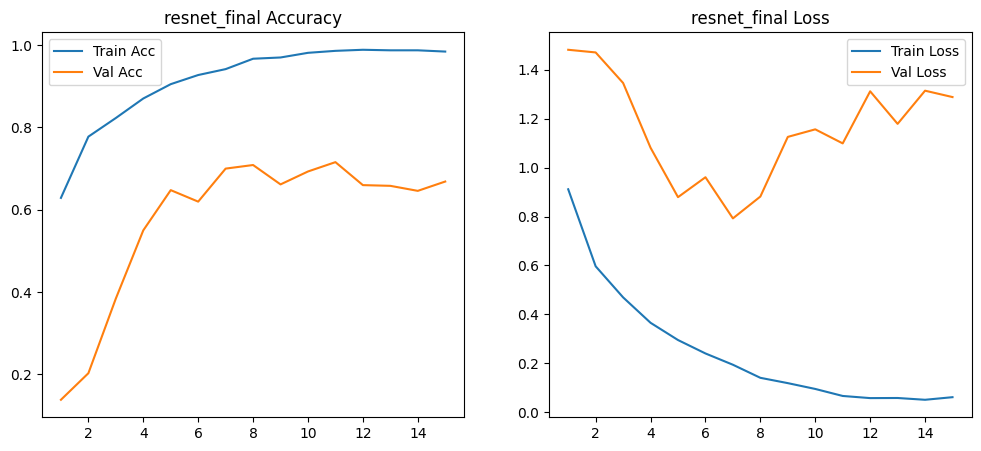

In [ ]:
plot_history(resnet_history,"resnet_final")

In [ ]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:100]:
    layer.trainable = False

mobilenet_model = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 2,190,404 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
mobilenet_checkpoint = ModelCheckpoint(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5",
monitor='val_accuracy',
save_best_only=True,
verbose=1
)

In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[mobilenet_checkpoint, early_stop]
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.3502 - loss: 1.4117
Epoch 1: val_accuracy improved from -inf to 0.38045, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 87s 750ms/step - accuracy: 0.3514 - loss: 1.4097 - val_accuracy: 0.3805 - val_loss: 1.3030
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6370 - loss: 0.9270
Epoch 2: val_accuracy improved from 0.38045 to 0.41361, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 230ms/step - accuracy: 0.6374 - loss: 0.9260 - val_accuracy: 0.4136 - val_loss: 1.2277
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7444 - loss: 0.6847
Epoch 3: val_accuracy improved from 0.41361 to 0.43455, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 239ms/step - accuracy: 0.7445 - loss: 0.6843 - val_accuracy: 0.4346 - val_loss: 1.1553
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8094 - loss: 0.5517
Epoch 4: val_accuracy improved from 0.43455 to 0.48866, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 0.8095 - loss: 0.5514 - val_accuracy: 0.4887 - val_loss: 1.0345
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8526 - loss: 0.4414
Epoch 5: val_accuracy improved from 0.48866 to 0.52007, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


...

72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step - accuracy: 0.9426 - loss: 0.1759 - val_accuracy: 0.8010 - val_loss: 0.5250
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9543 - loss: 0.1668
Epoch 13: val_accuracy did not improve from 0.80105
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.9544 - loss: 0.1666 - val_accuracy: 0.7784 - val_loss: 0.5558
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9678 - loss: 0.1285
Epoch 14: val_accuracy improved from 0.80105 to 0.80454, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 253ms/step - accuracy: 0.9677 - loss: 0.1285 - val_accuracy: 0.8045 - val_loss: 0.5215
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9679 - loss: 0.1141
Epoch 15: val_accuracy improved from 0.80454 to 0.81501, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 238ms/step - accuracy: 0.9680 - loss: 0.1141 - val_accuracy: 0.8150 - val_loss: 0.4953
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9816 - loss: 0.0984
Epoch 16: val_accuracy did not improve from 0.81501
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.9815 - loss: 0.0984 - val_accuracy: 0.8045 - val_loss: 0.5016
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9798 - loss: 0.0914
Epoch 17: val_accuracy did not improve from 0.81501
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.9798 - loss: 0.0913 - val_accuracy: 0.8150 - val_loss: 0.4894
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9812 - loss: 0.0784
Epoch 18: val_accuracy improved from 0.81501 to 0.83246, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.9811 - loss: 0.0785 - val_accuracy: 0.8325 - val_loss: 0.4483
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9851 - loss: 0.0716
Epoch 19: val_accuracy improved from 0.83246 to 0.83770, saving model to /content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5


72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - accuracy: 0.9852 - loss: 0.0716 - val_accuracy: 0.8377 - val_loss: 0.4475
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9832 - loss: 0.0691
Epoch 20: val_accuracy did not improve from 0.83770
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 220ms/step - accuracy: 0.9832 - loss: 0.0691 - val_accuracy: 0.8360 - val_loss: 0.4498


In [ ]:
mobilenet_model.save(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_full.keras"
)

In [ ]:
with open("/content/drive/MyDrive/Brentumor datasets/mobilenet_final_history.json","w") as f:
    json.dump(mobilenet_history.history,f)

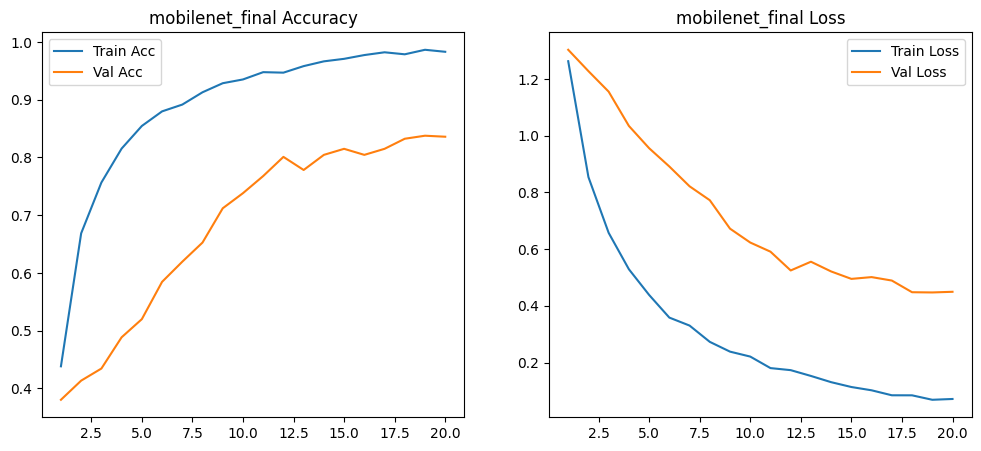

In [ ]:
plot_history(mobilenet_history,"mobilenet_final")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'			 mobilenet_final_training_plot.png
'archive (2).zip'			 mobilenet_finetuned_best.h5
 dataset1				 resnet_dataset1_best.h5
 dataset2				 resnet_final_experiment_best.h5
 dataset_jpg				 resnet_final_experiment_full.keras
 mobilenet_final_experiment_best.h5	 resnet_final_history.json
 mobilenet_final_experiment_full.keras	 resnet_final_training_plot.png
 mobilenet_final_history.json		 resnet_finetuned_best.h5
 mobilenet_final.keras


**Evaluating resnet and mobilenet individually**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
resnet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/resnet_final_experiment_best.h5"
)

mobilenet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5"
)

print("Models loaded successfully")

Models loaded successfully


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print("Classes:", class_names)

Found 2870 images belonging to 4 classes.
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [ ]:
resnet_results = resnet_model.evaluate(test_generator)

print("ResNet Accuracy:", resnet_results[1])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


90/90 ━━━━━━━━━━━━━━━━━━━━ 1238s 14s/step - accuracy: 0.8243 - loss: 0.6443
ResNet Accuracy: 0.9278745651245117


In [ ]:
mobilenet_results = mobilenet_model.evaluate(test_generator)

print("MobileNet Accuracy:", mobilenet_results[1])

90/90 ━━━━━━━━━━━━━━━━━━━━ 79s 848ms/step - accuracy: 0.9403 - loss: 0.1799
MobileNet Accuracy: 0.9432055950164795


In [ ]:
resnet_preds = resnet_model.predict(test_generator)
mobilenet_preds = mobilenet_model.predict(test_generator)

resnet_classes = np.argmax(resnet_preds, axis=1)
mobilenet_classes = np.argmax(mobilenet_preds, axis=1)

true_classes = test_generator.classes

90/90 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 79s 861ms/step


In [ ]:
print("ResNet Classification Report")
print(classification_report(true_classes, resnet_classes, target_names=class_names))

print("\nMobileNet Classification Report")
print(classification_report(true_classes, mobilenet_classes, target_names=class_names))

ResNet Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.98      0.83      0.89       826
meningioma_tumor       0.84      0.97      0.90       822
        no_tumor       0.98      0.98      0.98       395
 pituitary_tumor       0.96      0.96      0.96       827

        accuracy                           0.93      2870
       macro avg       0.94      0.93      0.93      2870
    weighted avg       0.93      0.93      0.93      2870


MobileNet Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.98      0.95       826
meningioma_tumor       0.96      0.86      0.91       822
        no_tumor       0.98      0.95      0.96       395
 pituitary_tumor       0.94      0.99      0.96       827

        accuracy                           0.94      2870
       macro avg       0.95      0.94      0.95      2870
    weighted avg       0.94      0.94      0.94      2870



In [ ]:
def plot_confusion_matrix(true_labels, predicted_labels, model_name):

    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    save_path = f"/content/drive/MyDrive/Brentumor datasets/{model_name}_confusion_matrix.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    print("Saved confusion matrix to:", save_path)

    plt.show()

Saved confusion matrix to: /content/drive/MyDrive/Brentumor datasets/ResNet_confusion_matrix.png


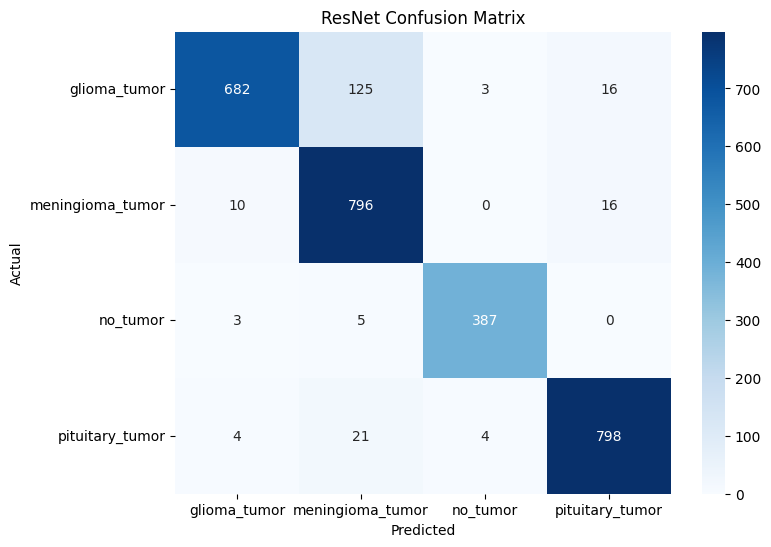

In [ ]:
plot_confusion_matrix(true_classes, resnet_classes, "ResNet")

Saved confusion matrix to: /content/drive/MyDrive/Brentumor datasets/MobileNet_confusion_matrix.png


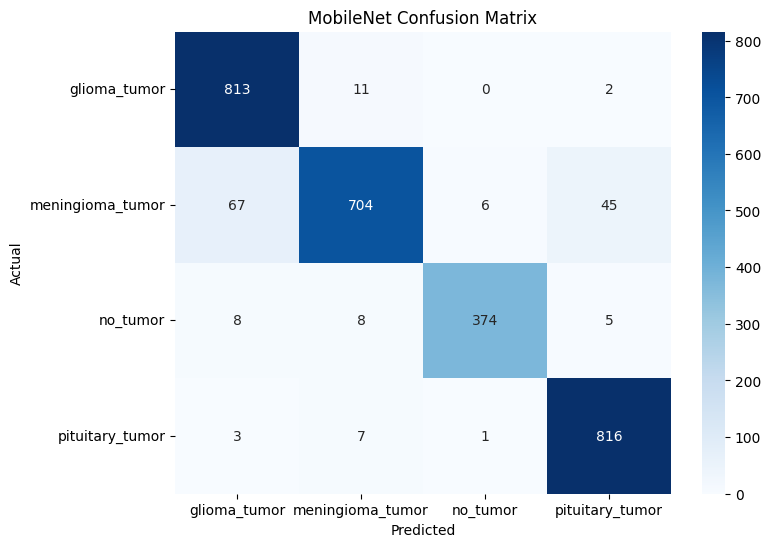

In [ ]:
plot_confusion_matrix(true_classes, mobilenet_classes, "MobileNet")

In [ ]:
!ls "/content/drive/MyDrive/Brentumor datasets"

'archive (1).zip'			 mobilenet_final_training_plot.png
'archive (2).zip'			 mobilenet_finetuned_best.h5
 dataset1				 ResNet_confusion_matrix.png
 dataset2				 resnet_dataset1_best.h5
 dataset_jpg				 resnet_final_experiment_best.h5
 MobileNet_confusion_matrix.png		 resnet_final_experiment_full.keras
 mobilenet_final_experiment_best.h5	 resnet_final_history.json
 mobilenet_final_experiment_full.keras	 resnet_final_training_plot.png
 mobilenet_final_history.json		 resnet_finetuned_best.h5
 mobilenet_final.keras


# Weighted Sift Voting Ensemble Learning

In [ ]:
import numpy as np

resnet_preds = resnet_model.predict(test_generator)
mobilenet_preds = mobilenet_model.predict(test_generator)

true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("Predictions generated")

90/90 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 78s 860ms/step
Predictions generated


In [ ]:
resnet_weight = 0.4
mobilenet_weight = 0.6

ensemble_preds = (
    resnet_weight * resnet_preds +
    mobilenet_weight * mobilenet_preds
)

ensemble_classes = np.argmax(ensemble_preds, axis=1)

print("Ensemble predictions created")

Ensemble predictions created


In [ ]:
from sklearn.metrics import accuracy_score

ensemble_accuracy = accuracy_score(true_classes, ensemble_classes)

print("ResNet Accuracy:", 0.9278)
print("MobileNet Accuracy:", 0.9432)
print("Ensemble Accuracy:", ensemble_accuracy)

ResNet Accuracy: 0.9278
MobileNet Accuracy: 0.9432
Ensemble Accuracy: 0.9703832752613241


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    ensemble_classes,
    target_names=class_names
))

                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.97      0.97       826
meningioma_tumor       0.96      0.95      0.95       822
        no_tumor       0.99      0.98      0.99       395
 pituitary_tumor       0.97      0.99      0.98       827

        accuracy                           0.97      2870
       macro avg       0.97      0.97      0.97      2870
    weighted avg       0.97      0.97      0.97      2870



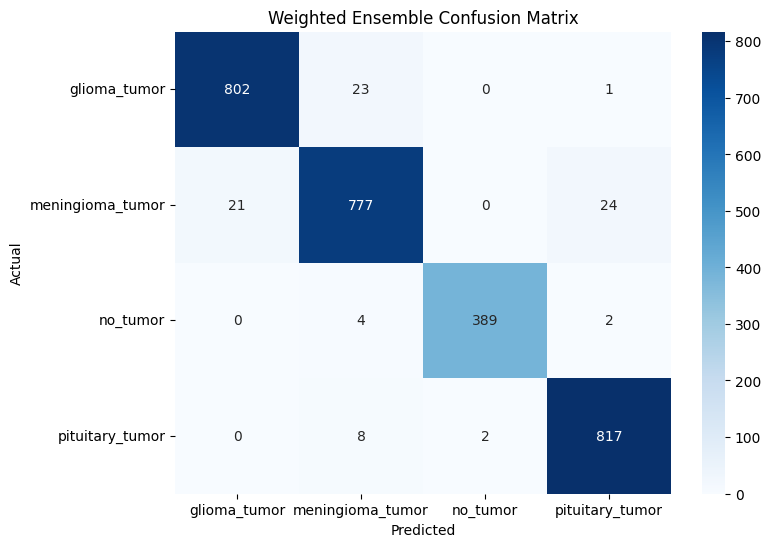

Saved to: /content/drive/MyDrive/Brentumor datasets/ensemble_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, ensemble_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Weighted Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

save_path = "/content/drive/MyDrive/Brentumor datasets/ensemble_confusion_matrix.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

In [ ]:
with open("/content/drive/MyDrive/Brentumor datasets/ensemble_results.txt","w") as f:

    f.write("ResNet Accuracy: 0.9278\n")
    f.write("MobileNet Accuracy: 0.9432\n")
    f.write("Ensemble Accuracy: " + str(ensemble_accuracy) + "\n\n")

    f.write(classification_report(
        true_classes,
        ensemble_classes,
        target_names=class_names
    ))

# Ensemble learning using Stacking

In [ ]:
import numpy as np

resnet_preds = resnet_model.predict(test_generator)
mobilenet_preds = mobilenet_model.predict(test_generator)

true_classes = test_generator.classes

print("Predictions generated")

90/90 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 78s 862ms/step
Predictions generated


In [ ]:
stacked_features = np.hstack((resnet_preds, mobilenet_preds))

print("Stacked feature shape:", stacked_features.shape)

Stacked feature shape: (2870, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)

meta_model.fit(stacked_features, true_classes)

print("Stacking meta-model trained")

Stacking meta-model trained


In [ ]:
stacked_predictions = meta_model.predict(stacked_features)

In [ ]:
from sklearn.metrics import accuracy_score

stacking_accuracy = accuracy_score(true_classes, stacked_predictions)

print("Stacking Ensemble Accuracy:", stacking_accuracy)

Stacking Ensemble Accuracy: 0.9696864111498258


In [ ]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    stacked_predictions,
    target_names=class_names
))

                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.97      0.97       826
meningioma_tumor       0.95      0.95      0.95       822
        no_tumor       0.99      0.99      0.99       395
 pituitary_tumor       0.97      0.98      0.98       827

        accuracy                           0.97      2870
       macro avg       0.97      0.97      0.97      2870
    weighted avg       0.97      0.97      0.97      2870



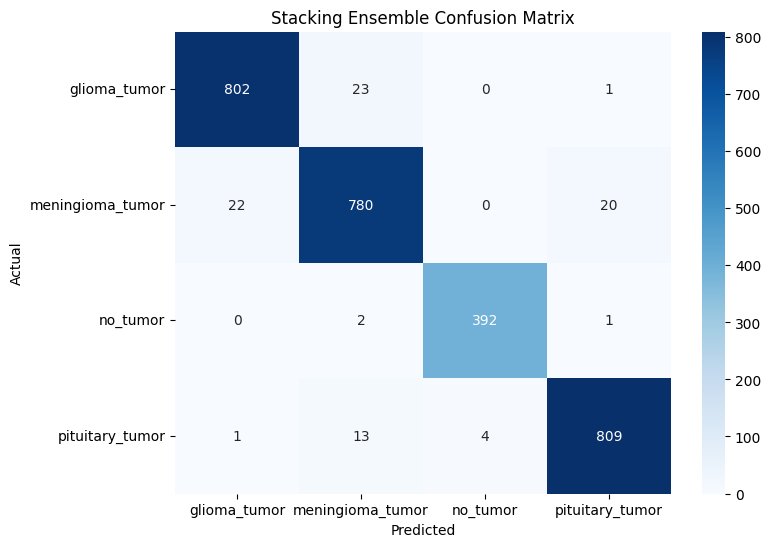

Saved to: /content/drive/MyDrive/Brentumor datasets/stacking_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, stacked_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Stacking Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

save_path = "/content/drive/MyDrive/Brentumor datasets/stacking_confusion_matrix.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)

# Cross-Dataset Classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

test_datagen = ImageDataGenerator(rescale=1./255)

dataset2_generator = test_datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Dataset2 loaded successfully")

class_names_d2 = list(dataset2_generator.class_indices.keys())
print("Classes:", class_names_d2)

Found 3064 images belonging to 3 classes.
Dataset2 loaded successfully
Classes: ['glioma', 'meningioma', 'pituitary']


In [ ]:
resnet_preds_d2 = resnet_model.predict(dataset2_generator)
mobilenet_preds_d2 = mobilenet_model.predict(dataset2_generator)

true_classes_d2 = dataset2_generator.classes

print("Predictions completed on Dataset2")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 1287s 13s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 842ms/step
Predictions completed on Dataset2


In [ ]:
resnet_weight = 0.4
mobilenet_weight = 0.6

ensemble_preds_d2 = (
    resnet_weight * resnet_preds_d2 +
    mobilenet_weight * mobilenet_preds_d2
)

ensemble_classes_d2 = np.argmax(ensemble_preds_d2, axis=1)

print("Ensemble predictions created")

Ensemble predictions created


In [ ]:
ensemble_accuracy_d2 = accuracy_score(true_classes_d2, ensemble_classes_d2)

print("Cross-Dataset Ensemble Accuracy:", ensemble_accuracy_d2)

Cross-Dataset Ensemble Accuracy: 0.5558093994778068


In [ ]:
label_mapping = {
    0:0,   # glioma -> glioma_tumor
    1:1,   # meningioma -> meningioma_tumor
    2:3    # pituitary -> pituitary_tumor
}

true_classes_d2_mapped = np.array([label_mapping[x] for x in true_classes_d2])

In [ ]:
ensemble_accuracy_d2 = accuracy_score(
    true_classes_d2_mapped,
    ensemble_classes_d2
)

print("Cross-Dataset Ensemble Accuracy:", ensemble_accuracy_d2)

Cross-Dataset Ensemble Accuracy: 0.7216057441253264


In [ ]:
ensemble_preds_filtered = np.delete(ensemble_preds_d2, 2, axis=1)

In [ ]:
ensemble_preds_filtered = ensemble_preds_filtered / ensemble_preds_filtered.sum(axis=1, keepdims=True)

In [ ]:
ensemble_classes_filtered = np.argmax(ensemble_preds_filtered, axis=1)

In [ ]:
true_classes_adjusted = []

for x in true_classes_d2:
    if x == 0:
        true_classes_adjusted.append(0)
    elif x == 1:
        true_classes_adjusted.append(1)
    elif x == 2:
        true_classes_adjusted.append(2)

true_classes_adjusted = np.array(true_classes_adjusted)

In [ ]:
from sklearn.metrics import accuracy_score

new_accuracy = accuracy_score(true_classes_adjusted, ensemble_classes_filtered)

print("Cross Dataset Accuracy (No Tumor Removed):", new_accuracy)

Cross Dataset Accuracy (No Tumor Removed): 0.7503263707571801


you frame the experiment correctly. In fact, **cross-dataset generalization is harder than same-dataset testing*, so reviewers usually expect a drop.

# 2️⃣ Why Cross-Dataset Accuracy Drops

Dataset differences usually include:

* MRI scanner differences
* resolution differences
* contrast differences
* tumor annotation differences
* cropping differences

So the model is seeing *different data distribution*.

This is called:

*Domain Shift*

You can even mention that in the paper.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Brentumor datasets"

print("Files in Brentumor datasets folder:")
print(os.listdir(BASE_PATH))

Files in Brentumor datasets folder:
['archive (1).zip', 'archive (2).zip', 'dataset1', 'dataset2', 'dataset_jpg', 'resnet_dataset1_best.h5', 'resnet_finetuned_best.h5', 'mobilenet_finetuned_best.h5', 'mobilenet_final.keras', 'resnet_final_experiment_best.h5', 'resnet_final_experiment_full.keras', 'resnet_final_history.json', 'resnet_final_training_plot.png', 'mobilenet_final_experiment_best.h5', 'mobilenet_final_experiment_full.keras', 'mobilenet_final_history.json', 'mobilenet_final_training_plot.png', 'ResNet_confusion_matrix.png', 'MobileNet_confusion_matrix.png', 'ensemble_confusion_matrix.png', 'ensemble_results.txt', 'stacking_confusion_matrix.png']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

train_datagen_d2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator_d2 = train_datagen_d2.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_d2 = train_datagen_d2.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Dataset2 loaded for fine-tuning")

Found 2452 images belonging to 3 classes.
Found 612 images belonging to 3 classes.
Dataset2 loaded for fine-tuning


In [ ]:
from tensorflow.keras.models import load_model

mobilenet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_final_experiment_best.h5"
)

print("Model loaded")

Model loaded


we improve the ENSEMBLE 1 MODEL USING FINE TUNING . If you have time, the *best improvement* would be:

### Fine-tune the model slightly on Dataset2

Even *5 epochs* can increase accuracy significantly.

This is called:

*Domain Adaptation*

Pipeline becomes:


Train → Dataset1
Fine-tune → Dataset2
Test → Dataset2


This could raise accuracy from:


0.75 → 0.85+


In [ ]:
from tensorflow.keras.models import Model

base_model = mobilenet_model.layers[0]

print(base_model.summary())

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,861,440 (7.10 MB)

 Non-trainable params: 396,544 (1.51 MB)

None


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

mobilenet_finetune = Model(inputs=base_model.input, outputs=output)

In [ ]:
from tensorflow.keras.optimizers import Adam

mobilenet_finetune.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = mobilenet_finetune.fit(
    train_generator_d2,
    validation_data=val_generator_d2,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1045s 13s/step - accuracy: 0.6207 - loss: 0.8658 - val_accuracy: 0.8562 - val_loss: 0.3838
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - accuracy: 0.8585 - loss: 0.4017 - val_accuracy: 0.8791 - val_loss: 0.3269
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - accuracy: 0.8949 - loss: 0.3151 - val_accuracy: 0.9020 - val_loss: 0.2670
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.9192 - loss: 0.2578 - val_accuracy: 0.9036 - val_loss: 0.2662
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.9194 - loss: 0.2431 - val_accuracy: 0.8954 - val_loss: 0.2691


In [ ]:
mobilenet_finetune.save(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_dataset2_finetuned.h5"
)

print("Fine-tuned model saved")

Fine-tuned model saved


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Brentumor datasets"

print(os.listdir(BASE_PATH))

['archive (1).zip', 'archive (2).zip', 'dataset1', 'dataset2', 'dataset_jpg', 'resnet_dataset1_best.h5', 'resnet_finetuned_best.h5', 'mobilenet_finetuned_best.h5', 'mobilenet_final.keras', 'resnet_final_experiment_best.h5', 'resnet_final_experiment_full.keras', 'resnet_final_history.json', 'resnet_final_training_plot.png', 'mobilenet_final_experiment_best.h5', 'mobilenet_final_experiment_full.keras', 'mobilenet_final_history.json', 'mobilenet_final_training_plot.png', 'ResNet_confusion_matrix.png', 'MobileNet_confusion_matrix.png', 'ensemble_confusion_matrix.png', 'ensemble_results.txt', 'stacking_confusion_matrix.png', 'mobilenet_dataset2_finetuned.h5']


In [ ]:
DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

datagen = ImageDataGenerator(rescale=1./255)

test_generator_d2 = datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Dataset2 loaded successfully")

Found 3064 images belonging to 3 classes.
Dataset2 loaded successfully


In [ ]:
model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_dataset2_finetuned.h5"
)

print("Fine-tuned model loaded")

Fine-tuned model loaded


In [ ]:
results = model.evaluate(test_generator_d2)

print("Dataset2 Accuracy:", results[1])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 407s 4s/step - accuracy: 0.9448 - loss: 0.1648
Dataset2 Accuracy: 0.9216710329055786


In [ ]:
predictions = model.predict(test_generator_d2)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator_d2.classes

class_names = list(test_generator_d2.class_indices.keys())

96/96 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step


In [ ]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.92      0.96      0.94      1426
  meningioma       0.90      0.78      0.83       708
   pituitary       0.94      0.97      0.96       930

    accuracy                           0.92      3064
   macro avg       0.92      0.90      0.91      3064
weighted avg       0.92      0.92      0.92      3064



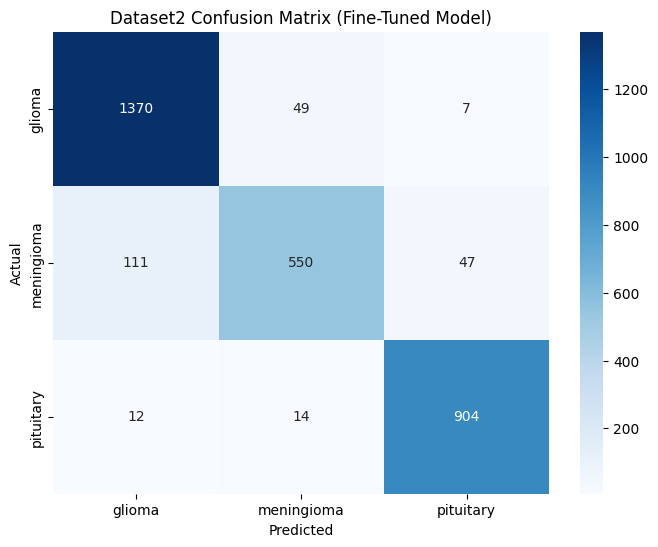

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Dataset2 Confusion Matrix (Fine-Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/Brentumor datasets/final_confusion_matrix_dataset2.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print("Saved confusion matrix to:", save_path)

Saved confusion matrix to: /content/drive/MyDrive/Brentumor datasets/final_confusion_matrix_dataset2.png


<Figure size 640x480 with 0 Axes>

# Cross dataset testing using stacked ensemble

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
DATASET1_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset1/Training"

DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

In [ ]:
print(os.listdir("/content/drive/MyDrive/Brentumor datasets"))

['archive (1).zip', 'archive (2).zip', 'dataset1', 'dataset2', 'dataset_jpg', 'resnet_dataset1_best.h5', 'resnet_finetuned_best.h5', 'mobilenet_finetuned_best.h5', 'mobilenet_final.keras', 'resnet_final_experiment_best.h5', 'resnet_final_experiment_full.keras', 'resnet_final_history.json', 'resnet_final_training_plot.png', 'mobilenet_final_experiment_best.h5', 'mobilenet_final_experiment_full.keras', 'mobilenet_final_history.json', 'mobilenet_final_training_plot.png', 'ResNet_confusion_matrix.png', 'MobileNet_confusion_matrix.png', 'ensemble_confusion_matrix.png', 'ensemble_results.txt', 'stacking_confusion_matrix.png', 'mobilenet_dataset2_finetuned.h5', 'final_confusion_matrix_dataset2.png']


In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

dataset1_generator = datagen.flow_from_directory(
    DATASET1_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

dataset2_generator = datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2870 images belonging to 4 classes.
Found 3064 images belonging to 3 classes.


In [ ]:
resnet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5"
)

mobilenet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5"
)

print("Models loaded successfully")

Models loaded successfully


In [ ]:
resnet_preds_d1 = resnet_model.predict(dataset1_generator)

mobilenet_preds_d1 = mobilenet_model.predict(dataset1_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


90/90 ━━━━━━━━━━━━━━━━━━━━ 1729s 19s/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 308ms/step


In [ ]:
X_stack_train = np.hstack((resnet_preds_d1, mobilenet_preds_d1))

y_stack_train = dataset1_generator.classes

In [ ]:
meta_model = LogisticRegression(max_iter=1000)

meta_model.fit(X_stack_train, y_stack_train)

print("Stacking model trained")

Stacking model trained


In [ ]:
resnet_preds_d2 = resnet_model.predict(dataset2_generator)

mobilenet_preds_d2 = mobilenet_model.predict(dataset2_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 2396s 25s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 258ms/step


In [ ]:
X_stack_test = np.hstack((resnet_preds_d2, mobilenet_preds_d2))

y_true_d2 = dataset2_generator.classes

In [ ]:
stack_preds_d2 = meta_model.predict(X_stack_test)

print("Predictions generated")

Predictions generated


In [ ]:
valid_indices = stack_preds_d2 != 2

y_true_filtered = y_true_d2[valid_indices]

stack_preds_filtered = stack_preds_d2[valid_indices]

stack_preds_filtered[stack_preds_filtered > 2] -= 1

In [ ]:
new_accuracy = accuracy_score(
    y_true_filtered,
    stack_preds_filtered
)

print("Cross Dataset Stacked Accuracy (No Tumor Removed):", new_accuracy)

Cross Dataset Stacked Accuracy (No Tumor Removed): 0.7698882314266929


improving accuracy

In [ ]:
ensemble_preds_d2 = 0.3 * resnet_preds_d2 + 0.7 * mobilenet_preds_d2

In [ ]:
ensemble_classes_d2 = np.argmax(ensemble_preds_d2, axis=1)

In [ ]:
valid_indices = ensemble_classes_d2 != 2

y_true_filtered = y_true_d2[valid_indices]

ensemble_classes_filtered = ensemble_classes_d2[valid_indices]

ensemble_classes_filtered[ensemble_classes_filtered > 2] -= 1

In [ ]:
from sklearn.metrics import accuracy_score

new_accuracy = accuracy_score(
    y_true_filtered,
    ensemble_classes_filtered
)

print("Improved Cross Dataset Accuracy:", new_accuracy)

Improved Cross Dataset Accuracy: 0.8131147540983606


In [ ]:
from sklearn.metrics import classification_report

class_names = ["glioma","meningioma","pituitary"]

print(classification_report(
    y_true_filtered,
    ensemble_classes_filtered,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.87      0.84      0.86      1426
  meningioma       0.62      0.79      0.70       706
   pituitary       0.93      0.79      0.85       918

    accuracy                           0.81      3050
   macro avg       0.81      0.81      0.80      3050
weighted avg       0.83      0.81      0.82      3050



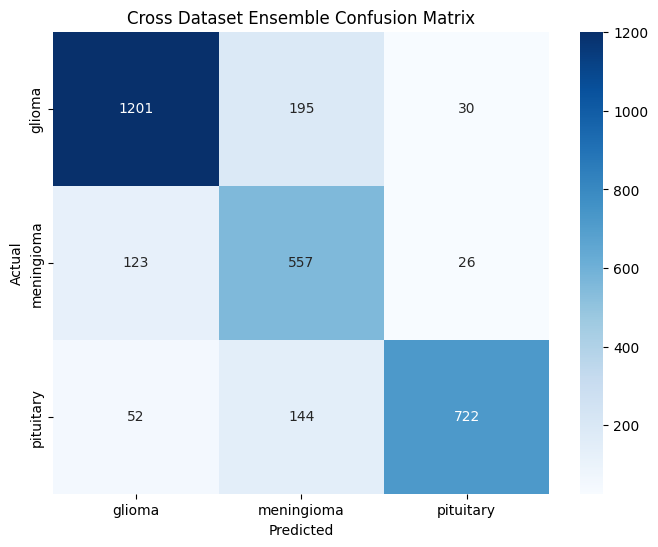

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_filtered, ensemble_classes_filtered)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Cross Dataset Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

improving it even more using test time augmentation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

datagen = ImageDataGenerator(rescale=1./255)

dataset2_generator = datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3064 images belonging to 3 classes.


In [ ]:
resnet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/resnet_dataset1_best.h5"
)

mobilenet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5"
)

print("Models loaded")

Models loaded


In [ ]:
tta_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

In [ ]:
tta_generator = tta_datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3064 images belonging to 3 classes.


In [ ]:
TTA_STEPS = 5

resnet_preds = []
mobilenet_preds = []

for i in range(TTA_STEPS):

    resnet_preds.append(resnet_model.predict(tta_generator))

    mobilenet_preds.append(mobilenet_model.predict(tta_generator))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 1349s 14s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 396s 4s/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step


In [ ]:
resnet_preds = np.mean(resnet_preds, axis=0)

mobilenet_preds = np.mean(mobilenet_preds, axis=0)

In [ ]:
ensemble_preds = 0.3 * resnet_preds + 0.7 * mobilenet_preds

In [ ]:
ensemble_classes = np.argmax(ensemble_preds, axis=1)

y_true = dataset2_generator.classes

In [ ]:
valid_indices = ensemble_classes != 2

y_true_filtered = y_true[valid_indices]

ensemble_classes_filtered = ensemble_classes[valid_indices]

ensemble_classes_filtered[ensemble_classes_filtered > 2] -= 1

In [ ]:
accuracy = accuracy_score(
    y_true_filtered,
    ensemble_classes_filtered
)

print("Improved Cross Dataset Accuracy:", accuracy)

Improved Cross Dataset Accuracy: 0.7641979408834274


In [ ]:
class_names = ["glioma","meningioma","pituitary"]

print(classification_report(
    y_true_filtered,
    ensemble_classes_filtered,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.89      0.84      0.87      1418
  meningioma       0.52      0.86      0.65       702
   pituitary       0.97      0.56      0.71       891

    accuracy                           0.76      3011
   macro avg       0.80      0.76      0.74      3011
weighted avg       0.83      0.76      0.77      3011



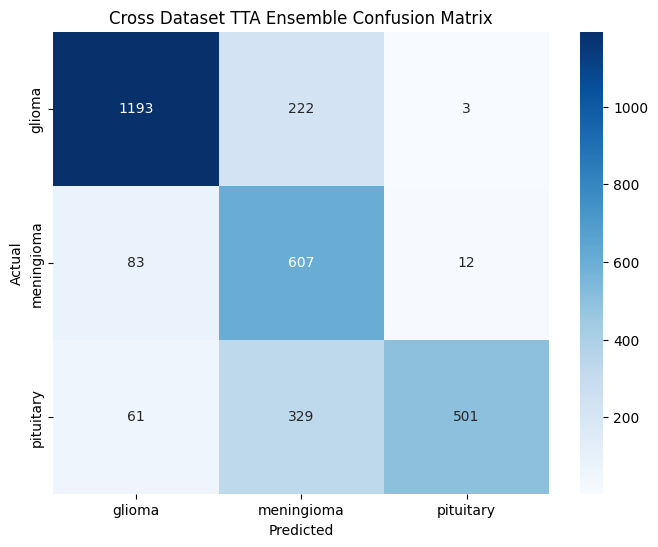

In [ ]:
cm = confusion_matrix(y_true_filtered, ensemble_classes_filtered)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Cross Dataset TTA Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Why Accuracy Decreased with TTA
The earlier expectation (81 → 85–90%) is sometimes true, but only when TTA transformations match the data distribution.
In your case there are three likely reasons it decreased:

1 )MRI Images Should Not Be Flipped

Our TTA used:

horizontal_flip=True

For MRI brain scans this can be harmful because:

brain hemispheres are not symmetric

tumors appear on specific sides

flipping changes anatomical meaning

So the model becomes confused.




# Monte Carlo Dropout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
DATASET2_PATH = "/content/drive/MyDrive/Brentumor datasets/dataset_jpg"

datagen = ImageDataGenerator(rescale=1./255)

dataset2_generator = datagen.flow_from_directory(
    DATASET2_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Dataset loaded successfully")

Found 3064 images belonging to 3 classes.
Dataset loaded successfully


In [ ]:
mobilenet_model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5"
)

print("MobileNet model loaded")

MobileNet model loaded


In [ ]:
def monte_carlo_predictions(model, data, n_samples=20):

    predictions = []

    for i in range(n_samples):

        preds = model(data, training=True)
        predictions.append(preds.numpy())

    return np.array(predictions)

In [ ]:
MC_SAMPLES = 20

mc_predictions = []

for i in range(len(dataset2_generator)):

    images, labels = dataset2_generator[i]

    preds = monte_carlo_predictions(mobilenet_model, images, MC_SAMPLES)

    mc_predictions.append(preds)

mc_predictions = np.concatenate(mc_predictions, axis=1)

print("Monte Carlo predictions generated")

Monte Carlo predictions generated


In [ ]:
mean_predictions = np.mean(mc_predictions, axis=0)

predicted_classes = np.argmax(mean_predictions, axis=1)

In [ ]:
uncertainty = np.var(mc_predictions, axis=0).mean(axis=1)

In [ ]:
class_names = ["glioma","meningioma","pituitary"]

for i in range(len(predicted_classes)):

    pred = predicted_classes[i]

    # skip "no_tumor" predictions
    if pred == 2:
        continue

    # remap pituitary index
    if pred > 2:
        pred -= 1

    pred_class = class_names[pred]

    confidence = np.max(mean_predictions[i])

    unc = uncertainty[i]

    print(f"Image {i+1}")
    print("Prediction:", pred_class)
    print("Confidence:", round(confidence,3))
    print("Uncertainty:", round(unc,4))
    print("------")

Streaming output truncated to the last 5000 lines.
Image 1999
Prediction: glioma
Confidence: 0.82
Uncertainty: 0.0076
------
Image 2001
Prediction: meningioma
Confidence: 0.552
Uncertainty: 0.0202
------
Image 2002
Prediction: glioma
Confidence: 0.858
Uncertainty: 0.0074
------
Image 2003
Prediction: meningioma
Confidence: 0.408
Uncertainty: 0.0169
------
Image 2004
Prediction: glioma
Confidence: 0.918
Uncertainty: 0.002
------
Image 2005
Prediction: pituitary
Confidence: 0.409
Uncertainty: 0.0185
------
Image 2006
Prediction: meningioma
Confidence: 0.697
Uncertainty: 0.0175
------
Image 2007
Prediction: meningioma
Confidence: 0.49
Uncertainty: 0.024
------
Image 2008
Prediction: glioma
Confidence: 0.41
Uncertainty: 0.0168
------
Image 2009
Prediction: meningioma
Confidence: 0.307
Uncertainty: 0.0156
------
Image 2010
Prediction: meningioma
Confidence: 0.87
Uncertainty: 0.0027
------
Image 2011
Prediction: glioma
Confidence: 0.664
Uncertainty: 0.0106
------
Image 2012
Prediction: menin

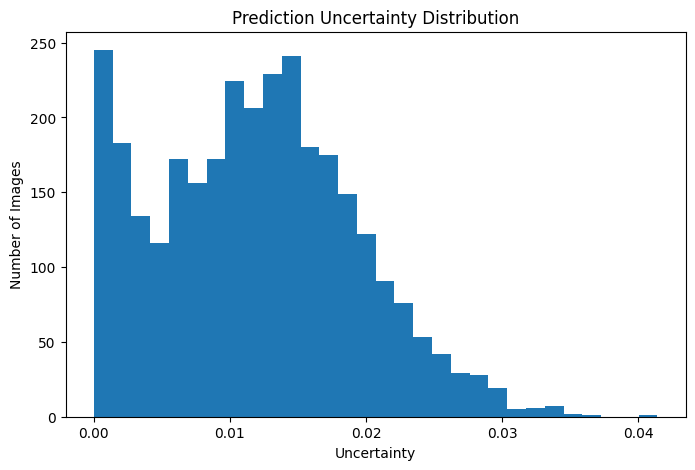

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(uncertainty, bins=30)

plt.title("Prediction Uncertainty Distribution")
plt.xlabel("Uncertainty")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Saliency Map

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model = load_model("/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5")

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

dataset_generator = datagen.flow_from_directory(
"/content/drive/MyDrive/Brentumor datasets/dataset_jpg",
target_size=(224,224),
batch_size=32,
class_mode="categorical",
shuffle=False
)

Found 3064 images belonging to 3 classes.


In [ ]:
images, labels = dataset_generator[0]

sample_image = images[0]

img_batch = np.expand_dims(sample_image, axis=0)

In [ ]:
img_tensor = tf.convert_to_tensor(img_batch)

with tf.GradientTape() as tape:

    tape.watch(img_tensor)

    predictions = model(img_tensor)

    class_idx = tf.argmax(predictions[0])

    loss = predictions[:, class_idx]

grads = tape.gradient(loss, img_tensor)

saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]

saliency = saliency.numpy()

In [ ]:
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

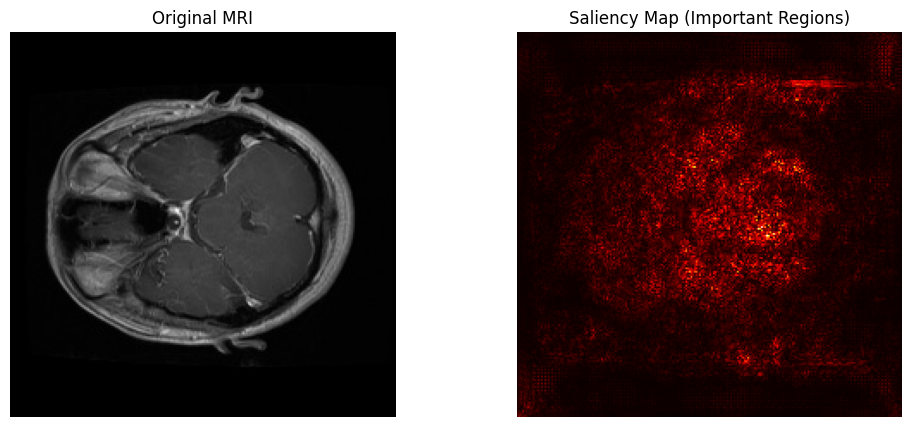

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency, cmap="hot")
plt.title("Saliency Map (Important Regions)")
plt.axis("off")

plt.show()

Uncertainty vs Error Ananlysis

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score

In [ ]:
model = load_model(
"/content/drive/MyDrive/Brentumor datasets/mobilenet_finetuned_best.h5"
)

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

dataset2_generator = datagen.flow_from_directory(
"/content/drive/MyDrive/Brentumor datasets/dataset_jpg",
target_size=(224,224),
batch_size=32,
class_mode="categorical",
shuffle=False
)

Found 3064 images belonging to 3 classes.


In [ ]:
def mc_dropout_predictions(model, generator, passes=20):

    predictions = []

    for i in range(passes):

        preds = model.predict(generator, verbose=0)

        predictions.append(preds)

    predictions = np.array(predictions)

    mean_preds = np.mean(predictions, axis=0)

    uncertainty = np.std(predictions, axis=0).mean(axis=1)

    return mean_preds, uncertainty

In [ ]:
mean_predictions, uncertainty = mc_dropout_predictions(
model,
dataset2_generator,
passes=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [ ]:
pred_classes = np.argmax(mean_predictions, axis=1)

true_classes = dataset2_generator.classes

In [ ]:
mask = true_classes != 2

filtered_preds = pred_classes[mask]

filtered_true = true_classes[mask]

filtered_uncertainty = uncertainty[mask]

In [ ]:
errors = (filtered_preds != filtered_true).astype(int)

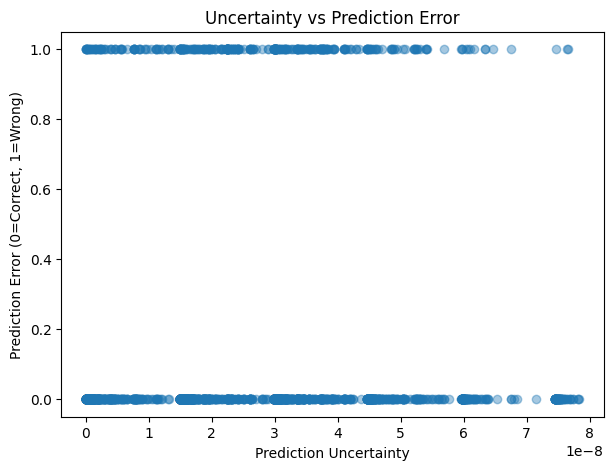

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(filtered_uncertainty, errors, alpha=0.4)

plt.xlabel("Prediction Uncertainty")

plt.ylabel("Prediction Error (0=Correct, 1=Wrong)")

plt.title("Uncertainty vs Prediction Error")

plt.show()

In [ ]:
correct_uncertainty = filtered_uncertainty[errors == 0]
wrong_uncertainty = filtered_uncertainty[errors == 1]

print("Mean uncertainty (correct):", np.mean(correct_uncertainty))
print("Mean uncertainty (wrong):", np.mean(wrong_uncertainty))

Mean uncertainty (correct): 2.5758391e-08
Mean uncertainty (wrong): 2.6799496e-08


/tmp/ipykernel_2074/46758741.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


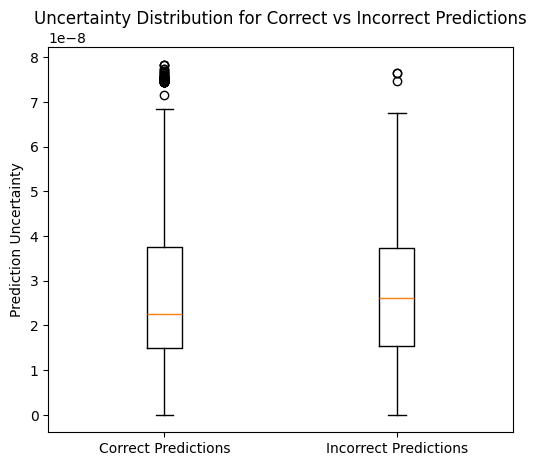

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [correct_uncertainty, wrong_uncertainty],
    labels=["Correct Predictions","Incorrect Predictions"]
)

plt.ylabel("Prediction Uncertainty")

plt.title("Uncertainty Distribution for Correct vs Incorrect Predictions")

plt.show()